## Question 4

In [ ]:
import numpy as np
import scipy as sp
from scipy import stats
import matplotlib.pyplot as plt

In [ ]:
x_data = np.arange(-10000, 10000, 0.001)
f0_data = stats.norm.pdf(x_data, -100, 2000)
f1_data = stats.norm.pdf(x_data, 1000, 2000)

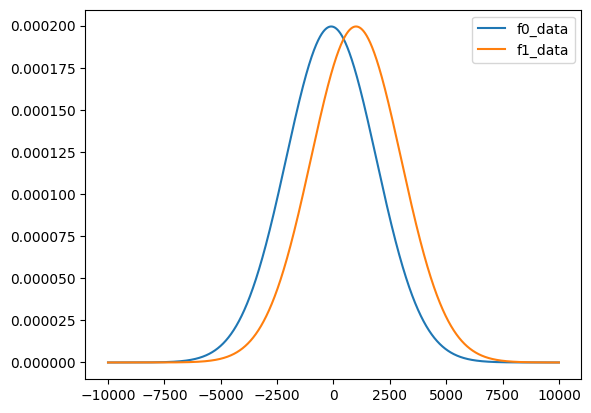

In [ ]:
plt.plot(x_data, f0_data, label='f0_data')
plt.plot(x_data, f1_data, label='f1_data')
plt.legend()
plt.show()

In [ ]:
p0_y = 0.5
p1_y = 0.5

In [ ]:
def computeQx(x):
  global p0_y
  global p1_y
  index = x + 10000
  f0_x = f0_data[index]
  f1_x = f1_data[index]
  sum = p0_y*f0_x + p1_y*f1_x
  q0_x = p0_y*f0_x / sum
  q1_x = p1_y*f1_x / sum
  if (q0_x >= q1_x) :
    ans = 0
  else :
    ans = 1
  return q0_x, q1_x, ans

In [ ]:
q0, q1, ans = computeQx(200)
q0

0.622339471825476

In [ ]:
q1

0.37766052817452395

In [ ]:
ans

0

In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.integrate import quad

In [ ]:
def gaussian_distribution(x, mean, std_dev):
    return (1 / (std_dev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std_dev)**2)

In [ ]:
mean1 = -1
mean2 = 1

In [ ]:
lower_limit1 = -np.inf
lower_limit2 = np.inf
upper_limit = (mean1 + mean2)/2
std_dev = 1

In [ ]:
TypeI_Error, _ = quad(gaussian_distribution, lower_limit1, upper_limit, args=(mean2, std_dev))

In [ ]:
TypeI_Error

0.15865525393145707

In [ ]:
TypeII_Error, _ = quad(gaussian_distribution, upper_limit, lower_limit2, args=(mean1, std_dev))

In [ ]:
TypeII_Error

0.15865525393145707

In [ ]:
loss = TypeI_Error + TypeII_Error
loss

0.31731050786291415

## Question 2

In [ ]:
P0_Y = 0.9
P1_Y = 0.1

In [ ]:
P = np.arange(0, 1, 0.001)

In [ ]:
P_error = 0.9*(P) + 0.1*(1 - P)

In [ ]:
import matplotlib.pyplot as plt

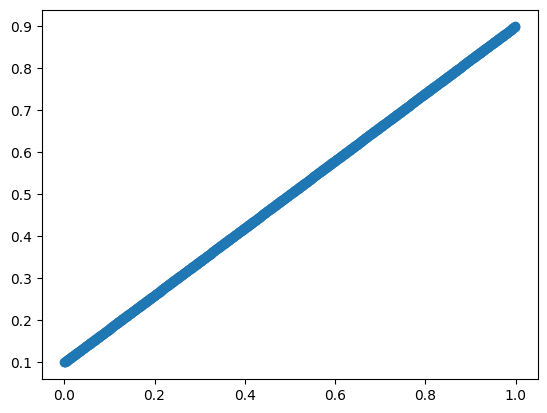

In [ ]:
plt.scatter(P, P_error)

## Question 1

```
# This is formatted as code
```



In [ ]:
n = 1
p = 0.4
points = 100

In [ ]:
binomial_points = np.random.binomial(n, p, points)

In [ ]:
binomial_points

array([0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1])

In [ ]:
def binomial_likelihood(p, x):
    return np.prod(p**x * (1 - p)**(1 - x))

In [ ]:
p_values = np.linspace(0, 1, 100)

In [ ]:
p_values

array([0.        , 0.01010101, 0.02020202, 0.03030303, 0.04040404,
       0.05050505, 0.06060606, 0.07070707, 0.08080808, 0.09090909,
       0.1010101 , 0.11111111, 0.12121212, 0.13131313, 0.14141414,
       0.15151515, 0.16161616, 0.17171717, 0.18181818, 0.19191919,
       0.2020202 , 0.21212121, 0.22222222, 0.23232323, 0.24242424,
       0.25252525, 0.26262626, 0.27272727, 0.28282828, 0.29292929,
       0.3030303 , 0.31313131, 0.32323232, 0.33333333, 0.34343434,
       0.35353535, 0.36363636, 0.37373737, 0.38383838, 0.39393939,
       0.4040404 , 0.41414141, 0.42424242, 0.43434343, 0.44444444,
       0.45454545, 0.46464646, 0.47474747, 0.48484848, 0.49494949,
       0.50505051, 0.51515152, 0.52525253, 0.53535354, 0.54545455,
       0.55555556, 0.56565657, 0.57575758, 0.58585859, 0.5959596 ,
       0.60606061, 0.61616162, 0.62626263, 0.63636364, 0.64646465,
       0.65656566, 0.66666667, 0.67676768, 0.68686869, 0.6969697 ,
       0.70707071, 0.71717172, 0.72727273, 0.73737374, 0.74747

In [ ]:
likelihood_values = [binomial_likelihood(p, binomial_points) for p in p_values]

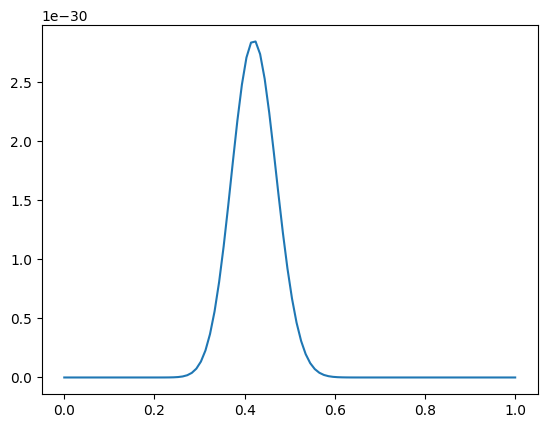

In [ ]:
plt.plot(p_values, likelihood_values)

In [ ]:
def neg_log_likelihood(p, data):
    likelihood = np.sum(data * np.log(p) + (1 - data) * np.log(1 - p))
    return likelihood

In [ ]:
log_likelihood_values = [neg_log_likelihood(p, binomial_points) for p in p_values]

<ipython-input-31-f5f49123cc00>:2: RuntimeWarning: divide by zero encountered in log
  likelihood = np.sum(data * np.log(p) + (1 - data) * np.log(1 - p))
<ipython-input-31-f5f49123cc00>:2: RuntimeWarning: invalid value encountered in multiply
  likelihood = np.sum(data * np.log(p) + (1 - data) * np.log(1 - p))


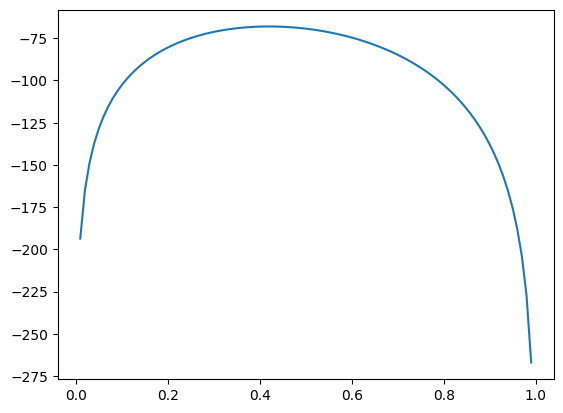

In [ ]:
plt.plot(p_values, log_likelihood_values)

## Question 3

In [ ]:
def calculate_posterior(probs, class_conditionals, i, j):
    num = probs[i] * class_conditionals[i][j]
    den = sum(probs[k] * class_conditionals[k][j] for k in range(len(probs)))
    return num / den

In [ ]:
def predict_class(x, posteriors):
    q0x = posteriors[0][x]
    q1x = posteriors[1][x]
    return 0 if q0x >= q1x else 1

In [ ]:
def classifier_error(probs, class_conditionals):
    prior0 = probs[0]
    prior1 = probs[1]
    posteriors = np.zeros_like(class_conditionals)

    for i in range(len(class_conditionals)):
        for j in range(len(class_conditionals[0])):
            posteriors[i][j] = calculate_posterior(probs, class_conditionals, i, j)

    classifier = posteriors
    error = 0
    TypeI_error = 0.0
    TypeII_error = 0.0
    for k in range(len(probs)):
        for l in range(len(class_conditionals[0])):
            if predict_class(l, classifier) != k:
                if (k == 0) :
                  TypeI_error += probs[k] * class_conditionals[k][l]
                else :
                  TypeII_error += probs[k] * class_conditionals[k][l]
                error += probs[k] * class_conditionals[k][l]

    return classifier, error, TypeI_error, TypeII_error

In [ ]:
probs = [0.4, 0.6]
class_conditionals = np.array([[0.2, 0.8], [0.7, 0.3]])

classifier, error, T1_err, T2_err = classifier_error(probs, class_conditionals)

In [ ]:
classifier

array([[0.16, 0.64],
       [0.84, 0.36]])

In [ ]:
error

0.26

In [ ]:
T1_err

0.08000000000000002

In [ ]:
T2_err

0.18